# OMPL IK Refactor Insight Notebook

Notebook ini fokus pada jalur produksi yang masih dipertahankan:

- `scripts/align_cubes_ompl_only.py`
- `scripts/align_tabung_ompl_only.py`
- scene `group_no_obs`, `ungroup_no_obs`, `group_obs`, dan `ungroup_obs`

Tahap refactor sengaja diringkas menjadi tiga tahap yang bisa diukur:

1. **Refactor 1**: baseline awal, arm belum stabil pada object jauh.
2. **Refactor 2**: stabilisasi IK/FK/OMPL untuk no-obstacle sampai 4/4.
3. **Refactor 3**: obstacle dibuat challenging tetapi reachable, lalu group/ungroup obs mencapai 4/4.

Tahap observability lama yang pernah disebut Refactor 1 tidak lagi dipisahkan karena insight utamanya, yaitu frame mismatch Pinocchio vs MuJoCo, langsung menjadi bagian dari Refactor 2.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == 'docs':
    ROOT = ROOT.parent
LOG_DIR = ROOT / 'logs'
DOC_DIR = ROOT / 'docs'
OUT_DIR = DOC_DIR / 'notebook_outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_LOGS = [
    'align_cubes_group_no_obs_20260526_232400.csv',
    'align_tabung_group_no_obs_20260526_231404.csv',
    'align_cubes_group_no_obs_20260527_204557.csv',
    'align_cubes_ungroup_no_obs_20260527_205745.csv',
    'align_tabung_group_no_obs_20260527_204857.csv',
    'align_tabung_ungroup_no_obs_20260527_205443.csv',
    'align_cubes_group_obs_20260527_215406.csv',
    'align_tabung_group_obs_20260527_205059.csv',
    'align_cubes_group_obs_20260528_215316.csv',
    'align_cubes_ungroup_obs_20260528_214730.csv',
    'align_tabung_group_obs_20260528_215541.csv',
    'align_tabung_ungroup_obs_20260528_215042.csv',
]

EVENT_LOGS = [
    'align_cubes_group_no_obs_20260526_232140_events.csv',
    'align_tabung_group_no_obs_20260526_231242_events.csv',
    'align_cubes_group_no_obs_20260527_204324_events.csv',
    'align_cubes_ungroup_no_obs_20260527_205514_events.csv',
    'align_tabung_group_no_obs_20260527_204615_events.csv',
    'align_tabung_ungroup_no_obs_20260527_205123_events.csv',
    'align_cubes_group_obs_20260527_215315_events.csv',
    'align_tabung_group_obs_20260527_204913_events.csv',
    'align_cubes_group_obs_20260528_215145_events.csv',
    'align_cubes_ungroup_obs_20260528_214513_events.csv',
    'align_tabung_group_obs_20260528_215325_events.csv',
    'align_tabung_ungroup_obs_20260528_214826_events.csv',
]

print(f'ROOT={ROOT}')
print(f'Summary logs available: {sum((LOG_DIR / f).exists() for f in SUMMARY_LOGS)}/{len(SUMMARY_LOGS)}')
print(f'Event logs available: {sum((LOG_DIR / f).exists() for f in EVENT_LOGS)}/{len(EVENT_LOGS)}')

ROOT=C:\projek\MVP-CTAMP-ROBOT
Summary logs available: 12/12
Event logs available: 12/12


In [2]:
def read_summary_logs():
    rows = []
    for name in SUMMARY_LOGS:
        path = LOG_DIR / name
        if not path.exists():
            rows.append({'file': name, 'missing': True})
            continue
        df = pd.read_csv(path)
        row = df.iloc[0].to_dict()
        row['file'] = name
        row['missing'] = False
        row.setdefault('scenario_type', 'static')
        if 'obstacle_mode' not in row or pd.isna(row.get('obstacle_mode')):
            row['obstacle_mode'] = 'obs' if '_obs_' in name or name.endswith('_obs.csv') else 'no_obs'
        if 'object_success_rate' not in row or pd.isna(row.get('object_success_rate')):
            row['object_success_rate'] = row.get('objects_moved', 0) / row.get('objects_total', 1)
        rows.append(row)
    return pd.DataFrame(rows)

summary_df = read_summary_logs()
summary_df[['file', 'task', 'scene', 'success', 'objects_moved', 'objects_total', 'object_success_rate', 'failed_json']]

,file,task,scene,success,objects_moved,objects_total,object_success_rate,failed_json
0,align_cubes_group_no_obs_20260526_232400.csv,align_cubes,group_no_obs,False,3,4,0.75,"[{""object_id"": ""cube4"", ""stage"": ""pick"", ""z"": ..."
1,align_tabung_group_no_obs_20260526_231404.csv,align_tabung,group_no_obs,False,2,4,0.50,"[{""object_id"": ""circle3"", ""stage"": ""pick"", ""z""..."
2,align_cubes_group_no_obs_20260527_204557.csv,align_cubes,group_no_obs,True,4,4,1.00,[]
3,align_cubes_ungroup_no_obs_20260527_205745.csv,align_cubes,ungroup_no_obs,True,4,4,1.00,[]
4,align_tabung_group_no_obs_20260527_204857.csv,align_tabung,group_no_obs,True,4,4,1.00,[]
5,align_tabung_ungroup_no_obs_20260527_205443.csv,align_tabung,ungroup_no_obs,True,4,4,1.00,[]
6,align_cubes_group_obs_20260527_215406.csv,align_cubes,group_obs,False,1,4,0.25,"[{""object_id"": ""cube2"", ""stage"": ""precheck"", ""..."
7,align_tabung_group_obs_20260527_205059.csv,align_tabung,group_obs,False,1,4,0.25,"[{""object_id"": ""circle3"", ""stage"": ""precheck"",..."
8,align_cubes_group_obs_20260528_215316.csv,align_cubes,group_obs,True,4,4,1.00,[]
9,align_cubes_ungroup_obs_20260528_214730.csv,align_cubes,ungroup_obs,True,4,4,1.00,[]


## Insight 1 - Baseline vs Final

Baseline awal menunjukkan arm bukan gagal karena OMPL tidak bisa jalan sama sekali. Ia bisa menyelesaikan sebagian object, tetapi gagal pada object yang lebih jauh atau lebih sensitif terhadap grasp:

- Cubes baseline: 3/4, `cube4` gagal pick.
- Tabung baseline: 2/4, `circle3` dan `circle4` gagal pick.

Setelah Refactor 2, seluruh no-obstacle group/ungroup menjadi 4/4. Setelah Refactor 3, seluruh obstacle group/ungroup juga menjadi 4/4.

In [3]:
metrics_df = pd.read_csv(DOC_DIR / 'refactor_metrics.csv')
progress_df = metrics_df[metrics_df['section'] == 'progress'].copy()
progress_df['label'] = progress_df['milestone'] + '\n' + progress_df['scope']
progress_df[['milestone', 'scope', 'moved', 'total', 'rate', 'note', 'file']]

,milestone,scope,moved,total,rate,note,file
0,Refactor 1,cubes group_no_obs,3,4,0.75,baseline: far cube pick failed,align_cubes_group_no_obs_20260526_232400.csv
1,Refactor 1,tabung group_no_obs,2,4,0.50,baseline: far cylinders failed pick,align_tabung_group_no_obs_20260526_231404.csv
2,Refactor 2,cubes group_no_obs,4,4,1.00,Pinocchio base-frame + grasp fix,align_cubes_group_no_obs_20260527_204557.csv
3,Refactor 2,cubes ungroup_no_obs,4,4,1.00,target ordering + object guard,align_cubes_ungroup_no_obs_20260527_205745.csv
4,Refactor 2,tabung group_no_obs,4,4,1.00,candidate retry + cylinder guard,align_tabung_group_no_obs_20260527_204857.csv
5,Refactor 2,tabung ungroup_no_obs,4,4,1.00,candidate retry + cylinder guard,align_tabung_ungroup_no_obs_20260527_205443.csv
6,Refactor 3 baseline,cubes group_obs,1,4,0.25,NEAR skip + place slip near obstacle,align_cubes_group_obs_20260527_215406.csv
7,Refactor 3 baseline,tabung group_obs,1,4,0.25,NEAR skip + cylinder displaced,align_tabung_group_obs_20260527_205059.csv
8,Refactor 3,cubes group_obs,4,4,1.00,challenging diagonal obstacle + cautious obs e...,align_cubes_group_obs_20260528_215316.csv
9,Refactor 3,cubes ungroup_obs,4,4,1.00,challenging diagonal obstacle + cautious obs e...,align_cubes_ungroup_obs_20260528_214730.csv


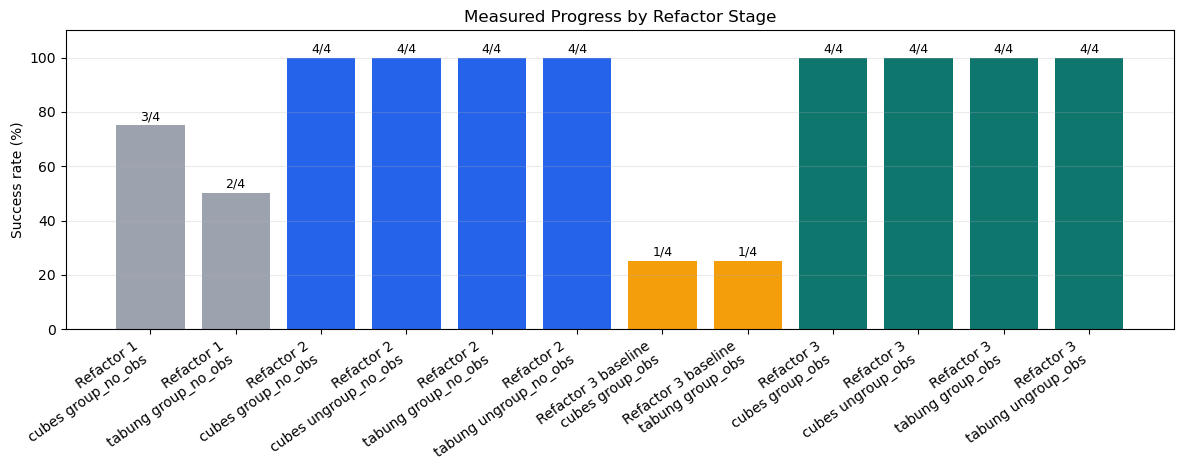

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.8))
colors = progress_df['milestone'].map({
    'Refactor 1': '#9ca3af',
    'Refactor 2': '#2563eb',
    'Refactor 3 baseline': '#f59e0b',
    'Refactor 3': '#0f766e',
}).fillna('#6b7280')
ax.bar(range(len(progress_df)), progress_df['rate'] * 100, color=colors)
ax.set_ylim(0, 110)
ax.set_ylabel('Success rate (%)')
ax.set_title('Measured Progress by Refactor Stage')
ax.set_xticks(range(len(progress_df)))
ax.set_xticklabels(progress_df['label'], rotation=35, ha='right')
for i, row in progress_df.reset_index(drop=True).iterrows():
    ax.text(i, row['rate'] * 100 + 2, f"{int(row['moved'])}/{int(row['total'])}", ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
fig.savefig(OUT_DIR / 'refactor_stage_success.png', dpi=160)
progress_df.to_csv(OUT_DIR / 'refactor_stage_summary.csv', index=False)
plt.show()

## Insight 2 - Failure Reason yang Benar-benar Mengubah Desain

Kegagalan yang dipakai sebagai dasar refactor bukan semua log historis, melainkan failure yang punya sinyal desain:

- `object_not_lifted_after_pick`: grasp terlalu rendah, offset kurang tepat, atau object jauh membuat finger/table contact lebih mudah muncul.
- `object_near_obstacle_safety_skip`: object sebenarnya masih reachable, tetapi guard lama terlalu takut sehingga task berhenti sebelum dicoba.
- `object_not_on_target_after_place`: obstacle/corridor terlalu dekat sehingga object slip saat place.
- `object_displaced_below_table`: retry cylinder yang buruk bisa mendorong object keluar workspace.

Refactor 2 fokus pada IK/FK dan valid candidate. Refactor 3 fokus pada obstacle guard, cautious execution, dan retry yang recoverable.

In [5]:
def parse_failure_reasons(row):
    raw = row.get('failure_reason_counts_json')
    if isinstance(raw, str) and raw.strip() and raw.strip() != '{}':
        try:
            return json.loads(raw)
        except json.JSONDecodeError:
            return {'unparsed_failure_json': 1}
    failed = row.get('failed_json')
    reasons = {}
    if isinstance(failed, str) and failed.strip() and failed.strip() != '[]':
        try:
            for item in json.loads(failed):
                reason = item.get('failure_reason') or item.get('stage') or 'unknown'
                reasons[reason] = reasons.get(reason, 0) + 1
        except json.JSONDecodeError:
            reasons['unparsed_failed_json'] = 1
    return reasons

reason_rows = []
for _, row in summary_df.iterrows():
    for reason, count in parse_failure_reasons(row).items():
        reason_rows.append({
            'file': row['file'],
            'task': row.get('task'),
            'scene': row.get('scene'),
            'reason': reason,
            'count': count,
        })
failure_reason_df = pd.DataFrame(reason_rows)
if not failure_reason_df.empty:
    display(failure_reason_df.sort_values(['scene', 'reason']))
    failure_reason_df.to_csv(OUT_DIR / 'failure_reason_summary.csv', index=False)
else:
    print('No failure reasons in curated final logs.')

,file,task,scene,reason,count
0,align_cubes_group_no_obs_20260526_232400.csv,align_cubes,group_no_obs,pick,1
1,align_tabung_group_no_obs_20260526_231404.csv,align_tabung,group_no_obs,pick,2
4,align_tabung_group_obs_20260527_205059.csv,align_tabung,group_obs,object_displaced_below_table,1
2,align_cubes_group_obs_20260527_215406.csv,align_cubes,group_obs,object_near_obstacle_safety_skip,2
5,align_tabung_group_obs_20260527_205059.csv,align_tabung,group_obs,object_near_obstacle_safety_skip,2
3,align_cubes_group_obs_20260527_215406.csv,align_cubes,group_obs,object_not_on_target_after_place,1


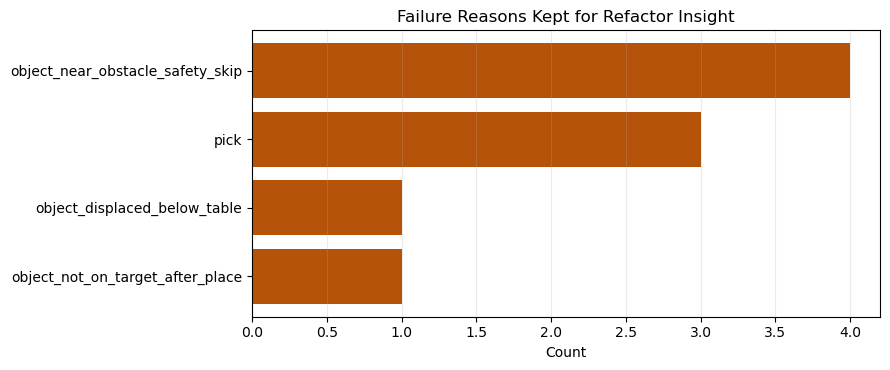

In [6]:
if not failure_reason_df.empty:
    agg = failure_reason_df.groupby('reason', as_index=False)['count'].sum().sort_values('count', ascending=False)
    fig, ax = plt.subplots(figsize=(9, 3.8))
    ax.barh(agg['reason'], agg['count'], color='#b45309')
    ax.invert_yaxis()
    ax.set_title('Failure Reasons Kept for Refactor Insight')
    ax.set_xlabel('Count')
    ax.grid(axis='x', alpha=0.25)
    plt.tight_layout()
    fig.savefig(OUT_DIR / 'failure_reason_summary.png', dpi=160)
    plt.show()

## Insight 3 - Final Matrix

Metrik final harus dibaca sebagai object-level success. Target acceptance saat ini adalah setiap command utama menyelesaikan 4/4 object:

- cubes group no_obs: 4/4
- cubes ungroup no_obs: 4/4
- tabung group no_obs: 4/4
- tabung ungroup no_obs: 4/4
- cubes group obs: 4/4
- cubes ungroup obs: 4/4
- tabung group obs: 4/4
- tabung ungroup obs: 4/4

In [7]:
final_df = metrics_df[metrics_df['section'] == 'final'].copy()
final_df['task_scene'] = final_df['task'] + '\n' + final_df['scene']
final_df[['task', 'scene', 'moved', 'total', 'rate', 'file']]

,task,scene,moved,total,rate,file
12,cubes,group_no_obs,4,4,1.0,align_cubes_group_no_obs_20260527_204557.csv
13,cubes,ungroup_no_obs,4,4,1.0,align_cubes_ungroup_no_obs_20260527_205745.csv
14,tabung,group_no_obs,4,4,1.0,align_tabung_group_no_obs_20260527_204857.csv
15,tabung,ungroup_no_obs,4,4,1.0,align_tabung_ungroup_no_obs_20260527_205443.csv
16,cubes,group_obs,4,4,1.0,align_cubes_group_obs_20260528_215316.csv
17,tabung,group_obs,4,4,1.0,align_tabung_group_obs_20260528_215541.csv
18,cubes,ungroup_obs,4,4,1.0,align_cubes_ungroup_obs_20260528_214730.csv
19,tabung,ungroup_obs,4,4,1.0,align_tabung_ungroup_obs_20260528_215042.csv


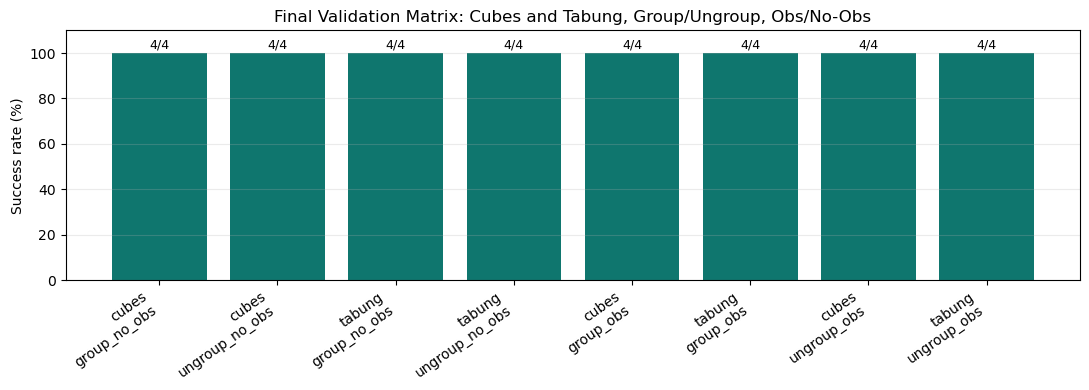

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
bar_colors = final_df['scene'].str.contains('obs').map({True: '#0f766e', False: '#2563eb'})
ax.bar(range(len(final_df)), final_df['rate'] * 100, color=bar_colors)
ax.set_ylim(0, 110)
ax.set_ylabel('Success rate (%)')
ax.set_title('Final Validation Matrix: Cubes and Tabung, Group/Ungroup, Obs/No-Obs')
ax.set_xticks(range(len(final_df)))
ax.set_xticklabels(final_df['task_scene'], rotation=35, ha='right')
for i, row in final_df.reset_index(drop=True).iterrows():
    ax.text(i, row['rate'] * 100 + 2, f"{int(row['moved'])}/{int(row['total'])}", ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
fig.savefig(OUT_DIR / 'final_validation_matrix.png', dpi=160)
final_df.to_csv(OUT_DIR / 'final_validation_matrix.csv', index=False)
plt.show()

## Insight 4 - Event Tracking untuk Obstacle

Obstacle terbaru tidak dibuat hanya sebagai dekorasi di depan object. Obstacle diletakkan diagonal dekat cluster object agar memicu `NEAR_CAUTIOUS`, tetapi tidak masuk `TOO_CLOSE`.

Yang perlu dilihat dari event log:

- `OBSTACLE_AVOID=NEAR_CAUTIOUS`: arm memilih high-clearance path.
- `CHECK_PICK=FAILED` lalu object masuk round berikutnya: failure parsial masih recoverable.
- `CHECK_PLACE=OK`: object final tetap dalam tolerance target.

In [9]:
def read_event_logs():
    frames = []
    for name in EVENT_LOGS:
        path = LOG_DIR / name
        if not path.exists():
            continue
        df = pd.read_csv(path)
        df['file'] = name
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

events_df = read_event_logs()
key_cols = [c for c in ['file', 'stage', 'status', 'object_id', 'phase', 'obstacle_mode', 'obstacle_distance', 'failure_reason', 'ompl_result', 'planner'] if c in events_df.columns]
events_df[key_cols].head(20) if not events_df.empty else 'No event logs loaded'

,file,stage,status,object_id,phase,obstacle_mode,obstacle_distance,failure_reason,ompl_result,planner
0,align_cubes_group_no_obs_20260526_232140_event...,SIM_LOAD,OK,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,align_cubes_group_no_obs_20260526_232140_event...,VIEWER_INIT,OK,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,align_cubes_group_no_obs_20260526_232140_event...,ARM_SELECT,OK,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,align_cubes_group_no_obs_20260526_232140_event...,ARM_SELECT,OK,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,align_cubes_group_no_obs_20260526_232140_event...,WARMUP,START,NaN,home,NaN,NaN,NaN,NaN,NaN
5,align_cubes_group_no_obs_20260526_232140_event...,WARMUP,OK,NaN,home,NaN,NaN,NaN,NaN,NaN
6,align_cubes_group_no_obs_20260526_232140_event...,WARMUP,START,NaN,grasp_ready,NaN,NaN,NaN,NaN,NaN
7,align_cubes_group_no_obs_20260526_232140_event...,WARMUP,OK,NaN,grasp_ready,NaN,NaN,NaN,NaN,NaN
8,align_cubes_group_no_obs_20260526_232140_event...,TASK_CONTEXT,START,NaN,align_cubes,NaN,NaN,NaN,NaN,NaN
9,align_cubes_group_no_obs_20260526_232140_event...,TASK_ROUND,START,NaN,align_cubes,NaN,NaN,NaN,NaN,NaN


In [10]:
if not events_df.empty and 'stage' in events_df.columns:
    stage_status = events_df.groupby(['stage', 'status'], dropna=False).size().reset_index(name='count')
    display(stage_status.sort_values('count', ascending=False).head(30))

    obstacle_events = events_df[events_df['stage'].eq('OBSTACLE_AVOID')] if 'stage' in events_df.columns else pd.DataFrame()
    if not obstacle_events.empty:
        cautious = obstacle_events.groupby(['file', 'status'], dropna=False).size().reset_index(name='count')
        display(cautious)
        cautious.to_csv(OUT_DIR / 'obstacle_event_summary.csv', index=False)

,stage,status,count
56,TRAJECTORY_WAYPOINT,EXEC,1753
16,IK_SOLVE,BACKEND_FALLBACK,1679
13,IK_CANDIDATE,OK,1625
14,IK_CANDIDATE,REJECT,1463
30,OMPL_PLAN,START,345
29,OMPL_PLAN,OK,345
55,TRAJECTORY_EXEC,START,345
54,TRAJECTORY_EXEC,OK,318
18,IK_SOLVE,OK,280
22,MOVE_POSE,START,272


,file,status,count
0,align_cubes_group_no_obs_20260526_232140_event...,CLEAR,6
1,align_cubes_group_no_obs_20260527_204324_event...,CLEAR,4
2,align_cubes_group_obs_20260527_215315_events.csv,CLEAR,1
3,align_cubes_group_obs_20260527_215315_events.csv,NEAR_CAUTIOUS,2
4,align_cubes_group_obs_20260528_215145_events.csv,CLEAR,2
5,align_cubes_group_obs_20260528_215145_events.csv,NEAR_CAUTIOUS,2
6,align_cubes_ungroup_no_obs_20260527_205514_eve...,CLEAR,4
7,align_cubes_ungroup_obs_20260528_214513_events...,CLEAR,2
8,align_cubes_ungroup_obs_20260528_214513_events...,NEAR_CAUTIOUS,2
9,align_tabung_group_no_obs_20260526_231242_even...,CLEAR,8


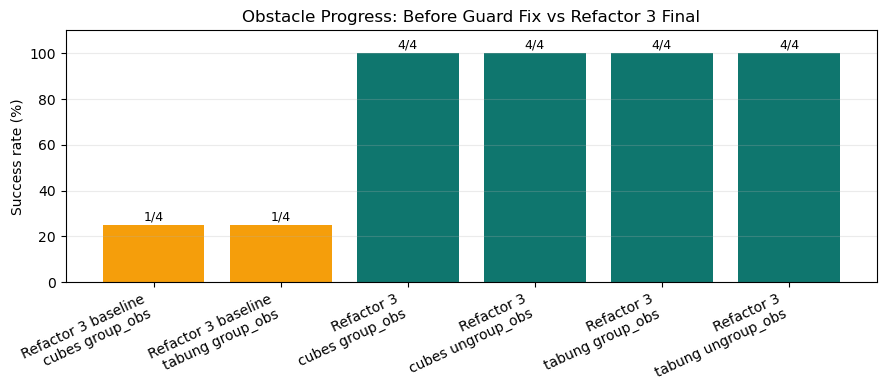

In [11]:
obs_progress = progress_df[progress_df['scope'].str.contains('group_obs|ungroup_obs', na=False)].copy()
fig, ax = plt.subplots(figsize=(9, 4))
colors = obs_progress['milestone'].map({'Refactor 3 baseline': '#f59e0b', 'Refactor 3': '#0f766e'}).fillna('#6b7280')
ax.bar(range(len(obs_progress)), obs_progress['rate'] * 100, color=colors)
ax.set_ylim(0, 110)
ax.set_ylabel('Success rate (%)')
ax.set_title('Obstacle Progress: Before Guard Fix vs Refactor 3 Final')
ax.set_xticks(range(len(obs_progress)))
ax.set_xticklabels(obs_progress['milestone'] + '\n' + obs_progress['scope'], rotation=25, ha='right')
for i, row in obs_progress.reset_index(drop=True).iterrows():
    ax.text(i, row['rate'] * 100 + 2, f"{int(row['moved'])}/{int(row['total'])}", ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
fig.savefig(OUT_DIR / 'obstacle_before_after.png', dpi=160)
plt.show()

## Kesimpulan Audit

1. Refactor 1/baseline membuktikan arm sudah bisa menyelesaikan sebagian task, tetapi gagal pada object jauh dan cylinder yang sensitif.
2. Refactor 2 mengubah failure utama dari masalah IK/grasp menjadi success 100% pada semua no-obstacle scene.
3. Refactor 3 tidak mematikan collision checking dan tidak menghapus obstacle. Obstacle dibuat cukup dekat untuk memaksa cautious path, tetapi tetap reachable, sehingga semua obstacle scene mencapai 4/4.
4. File log yang dipertahankan di repo sekarang hanya log yang mendukung angka di README dan notebook ini. Log run antara yang redundant dihapus supaya audit lebih jelas.